# Proyecto de Clasificación — Predicción de Aprobación de Préstamos (Loan Risk Prediction)

## Introducción y Objetivos

Este proyecto aborda un problema de **clasificación binaria**: predecir si una
solicitud de préstamo será **aprobada (1)** o **rechazada (0)** a partir de
las características socioeconómicas del solicitante (edad, ingresos, importe
solicitado, historial crediticio, experiencia laboral, nivel educativo,
ciudad y situación laboral).

El objetivo final es doble:
1. **Analítico**: construir, comparar y optimizar varios modelos de
   clasificación, manteniendo el **overfitting por debajo del 5%** (requisito
   del proyecto).
2. **Productivo**: dejar el modelo final exportado y listo para ser
   consumido por una aplicación (Streamlit) que reciba los datos de un
   cliente nuevo y devuelva la predicción, junto con el resto de
   componentes de nivel Medio/Avanzado (validación cruzada, tuning de
   hiperparámetros, sistema de feedback, ingesta de datos nuevos,
   dockerización, base de datos y tests unitarios).

### Dataset
Parte 01: `data/loan_risk_prediction_dataset.csv` — 5.000 solicitudes de préstamo con

Parte 02: `data/dataset_clean.csv`

Final: `data/dataset_final.csv`

las siguientes columnas:

| Columna | Descripción |
|---|---|
| `Age` | Edad del solicitante |
| `Income` | Ingresos anuales (USD) |
| `LoanAmount` | Importe del préstamo solicitado (USD) |
| `CreditScore` | Puntuación crediticia (300-850) |
| `YearsExperience` | Años de experiencia laboral |
| `Gender` | Género |
| `Education` | Nivel educativo |
| `City` | Ciudad de residencia |
| `EmploymentType` | Situación laboral |
| `LoanApproved` | **Variable objetivo**: 1 = aprobado, 0 = rechazado |

### Índice de Contenidos

PARTE 01
* [FASE 1 - Carga y Auditoría de Datos](#fase-1)
* [FASE 2 - Limpieza de Datos y Outliers](#fase-2)
* [FASE 3 - EDA Multivariado](#fase-3)

PARTE 02
* [FASE 4 - Train/Test Split y Pipeline de Preprocesado](#fase-4)
* [FASE 5 - Comparativa de Modelos de Clasificación](#fase-5)
* [FASE 6 - Validación Cruzada y Optimización de Hiperparámetros (Optuna)](#fase-6)
* [FASE 7 - Modelo Final y Control de Overfitting](#fase-7)
* [FASE 8 - Importancia de Variables](#fase-8)
* [FASE 9 - Exportación del Modelo y Metadata](#fase-9)
* [FASE 10 - Sistema de Feedback e Ingesta de Datos Nuevos](#fase-10)
* [Conclusiones Finales](#conclusiones)

In [4]:
import sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install streamlit
import streamlit as st
import joblib
import sklearn
import seaborn as sns

import os
os.makedirs("assets", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Modo info para la creación del entorno
print(f"streamlit=={st.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'pandas'

<a id='fase-1'></a>
## FASE 1 - Carga del Dataset y Auditoría de Calidad

Empezamos por cargar los datos y hacer un diagnóstico inicial: tamaño,
tipos de variables, nulos, duplicados y estadísticos descriptivos. Esto
nos permite planificar la fase de limpieza con criterio antes de tocar
nada.

In [ ]:
data = pd.read_csv('data/loan_risk_prediction_dataset.csv')
df = pd.DataFrame(data)
df_copia = df.copy()

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(7)

Filas: 5000 | Columnas: 10


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1


In [ ]:
print("VALORES NULOS POR COLUMNA:\n")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.1f}% del dataset)")

VALORES NULOS POR COLUMNA:

Income         196
CreditScore    194
Education      198
dtype: int64

Total de filas con al menos un nulo: 570 (11.4% del dataset)


In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [ ]:
print("Filas duplicadas:", df.duplicated().sum())
print()
df.describe()

Filas duplicadas: 0



,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
# Auditoría de variables categóricas: categorías únicas por columna
columnas_objeto = df.select_dtypes(include='object').columns
print("AUDITORÍA DE VARIABLES CATEGÓRICAS:\n")
for col in columnas_objeto:
    print(f"{col:18s} -> {sorted(df[col].dropna().unique())}")

AUDITORÍA DE VARIABLES CATEGÓRICAS:

Gender             -> ['Female', 'Male']
Education          -> ['Bachelors', 'High School', 'Masters', 'PhD']
City               -> ['Chicago', 'Houston', 'New York', 'San Francisco']
EmploymentType     -> ['Salaried', 'Self-Employed', 'Unemployed']


**Diagnóstico inicial:**
- El dataset tiene 5.000 filas y 10 columnas, sin duplicados.
- Hay nulos en `Income`, `CreditScore` y `Education` (≈4% cada una): los
  trataremos con imputación en vez de eliminar filas, para no perder
  información.
- `Gender`, `City` y `EmploymentType` son categóricas nominales (sin orden).
- `Education` es categórica **ordinal**: tiene un orden lógico
  (High School < Bachelors < Masters < PhD).
- La variable objetivo `LoanApproved` es binaria (0/1).

<a id='fase-2'></a>
## FASE 2 - Limpieza de Datos y Gestión de Outliers

### Errores de captura de datos
`Income` y `LoanAmount` son magnitudes que, por definición de negocio, no
pueden ser negativas. Comprobamos cuántos registros incumplen esa regla:
son errores de captura, no outliers reales, así que los trataremos como
**valores inválidos → nulos** (y se imputarán igual que el resto de
nulos).

In [ ]:
print("Income negativo:", (df['Income'] < 0).sum(), "filas")
print("LoanAmount negativo:", (df['LoanAmount'] < 0).sum(), "filas")
df[(df['Income'] < 0) | (df['LoanAmount'] < 0)]\
    [['Age','Income','LoanAmount','CreditScore']].head()

Income negativo: 3 filas
LoanAmount negativo: 28 filas


,Age,Income,LoanAmount,CreditScore
17,39,35401.0,-4250.0,615.0
93,41,73864.0,-5728.0,525.0
439,68,32242.0,-2711.0,NaN
512,46,49172.0,-1595.0,803.0
609,52,39402.0,-2533.0,385.0


### Limpieza, corregimos los valores **negativos → NaN** y Tratamiento de Nulos

In [ ]:
# Columnas que, por definición de negocio, no pueden ser negativas.
# Un valor negativo aquí es un error de captura de datos, no un outlier real.
NON_NEGATIVE_COLUMNS = ["Income", "LoanAmount"]


def fix_invalid_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Corrige errores de captura que no tienen sentido de negocio:
    ingresos o importes de préstamo negativos. Los convertimos en
    NaN para que después el imputador del pipeline se encargue de
    rellenarlos de forma estadísticamente consistente.

    Esto se hace ANTES del train/test split porque es una regla de
    negocio determinista (valor < 0 -> inválido), no una estadística
    calculada sobre los datos, por lo que no genera fuga de información.
    """
    df = df.copy()
    for col in NON_NEGATIVE_COLUMNS:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    return df

In [ ]:
df = fix_invalid_values(df)
print("Income negativo tras la corrección:", (df['Income'] < 0).sum())
print("LoanAmount negativo tras la corrección:", (df['LoanAmount'] < 0).sum())
print()
print("Nulos tras marcar los inválidos como NaN:")
print(df.isnull().sum())

Income negativo tras la corrección: 0
LoanAmount negativo tras la corrección: 0

Nulos tras marcar los inválidos como NaN:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [ ]:
# Eliminar filas de nulos
df = df.dropna(subset=['Income', 'CreditScore', 'LoanAmount'])

In [ ]:
# Rellenar
df['Education'] = df['Education'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
Education,0
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
# Normalización de texto: eliminamos espacios en blanco y capitalizamos
# la primera letra de las columnas de tipo texto (dtype 'object')
for column in data.columns:
    if data[column].dtype == 'str':
        data[column] = data[column].str.strip().str.capitalize()
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [ ]:
#Limpieza duplicados
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4621 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4621 non-null   int64  
 1   Income           4621 non-null   float64
 2   LoanAmount       4621 non-null   float64
 3   CreditScore      4621 non-null   float64
 4   YearsExperience  4621 non-null   int64  
 5   Gender           4621 non-null   object 
 6   Education        4621 non-null   object 
 7   City             4621 non-null   object 
 8   EmploymentType   4621 non-null   object 
 9   LoanApproved     4621 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 397.1+ KB


### Detección visual de outliers (IQR)

Antes de decidir cómo tratarlos, visualizamos la distribución de las
variables numéricas con boxplots. Un valor se considera outlier (regla de
Tukey) si cae fuera de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

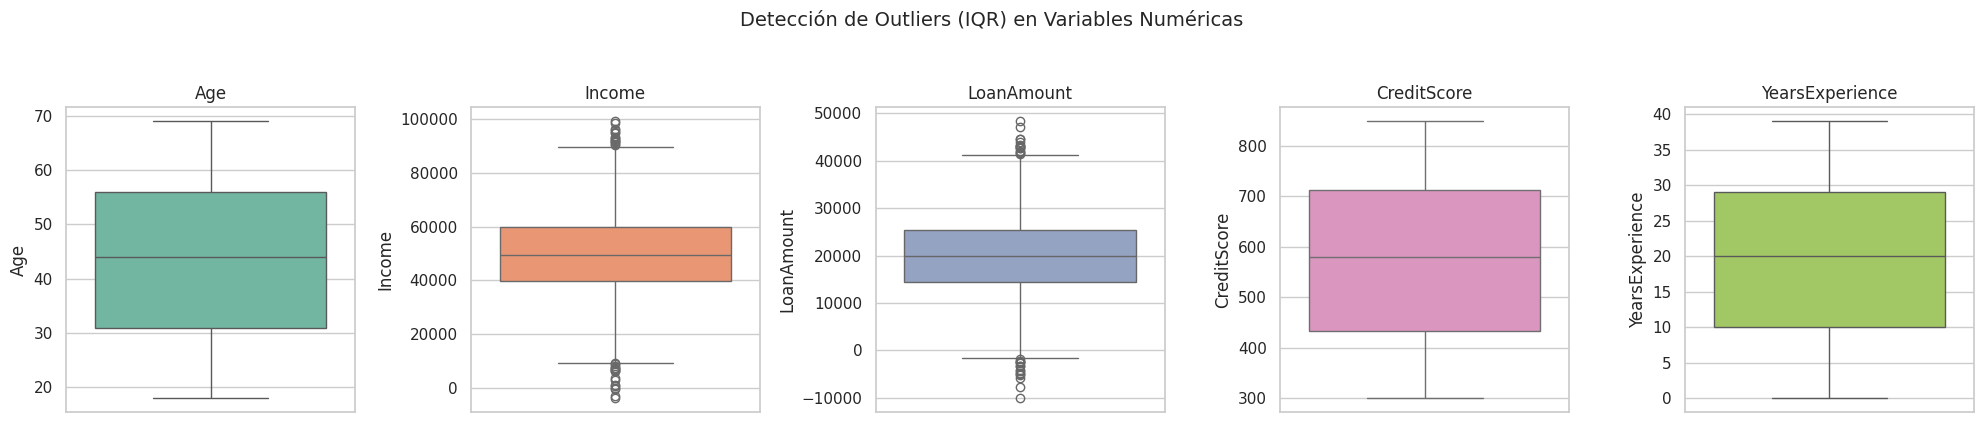

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
colors = sns.color_palette("Set2", len(num_cols))

for ax, col, color in zip(axes, num_cols, colors):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(col)

plt.suptitle('Detección de Outliers (IQR) en Variables Numéricas', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig('assets/boxplots_outliers.png', dpi=110, bbox_inches='tight')
plt.show()

### Tratamiento de Outliers (con IQR)

In [ ]:
# Identificar outliers en las variables financieras: 'Income',
# 'LoanAmount' y 'CreditScore'

def identificar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - (1.5 * IQR)
    limite_superior = Q3 + (1.5 * IQR)

    # Filtrar los outliers
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    print(f"Análisis de Outliers para la columna: {columna}")
    print(f"  - Límite Inferior aceptable: {limite_inferior:.2f}")
    print(f"  - Límite Superior aceptable: {limite_superior:.2f}")
    print(f"  - Cantidad de outliers detectados: {len(outliers)} de {len(dataframe)} filas ({len(outliers)/len(dataframe)*100:.2f}%)")
    return limite_inferior, limite_superior

# Ejecutar para tus variables financieras
lim_inf_age, lim_sup_age = identificar_outliers_iqr(df, 'Age')
lim_inf_income, lim_sup_income = identificar_outliers_iqr(df, 'Income')
lim_inf_restaurant_loanAmount, lim_sup_restaurant_loanAmount = identificar_outliers_iqr(df, 'LoanAmount')
lim_inf_restaurant_creditScore, lim_sup_restaurant_creditScore = identificar_outliers_iqr(df, 'CreditScore')
lim_inf_restaurant_yearsExperience, lim_sup_restaurant_yearsExperience = identificar_outliers_iqr(df, 'YearsExperience')

Análisis de Outliers para la columna: Age
  - Límite Inferior aceptable: -6.50
  - Límite Superior aceptable: 93.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)
Análisis de Outliers para la columna: Income
  - Límite Inferior aceptable: 9270.00
  - Límite Superior aceptable: 90150.00
  - Cantidad de outliers detectados: 32 de 4621 filas (0.69%)
Análisis de Outliers para la columna: LoanAmount
  - Límite Inferior aceptable: -1640.50
  - Límite Superior aceptable: 41483.50
  - Cantidad de outliers detectados: 30 de 4621 filas (0.65%)
Análisis de Outliers para la columna: CreditScore
  - Límite Inferior aceptable: 15.50
  - Límite Superior aceptable: 1131.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)
Análisis de Outliers para la columna: YearsExperience
  - Límite Inferior aceptable: -18.50
  - Límite Superior aceptable: 57.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)


NameError: name 'lim_sup_credit' is not defined

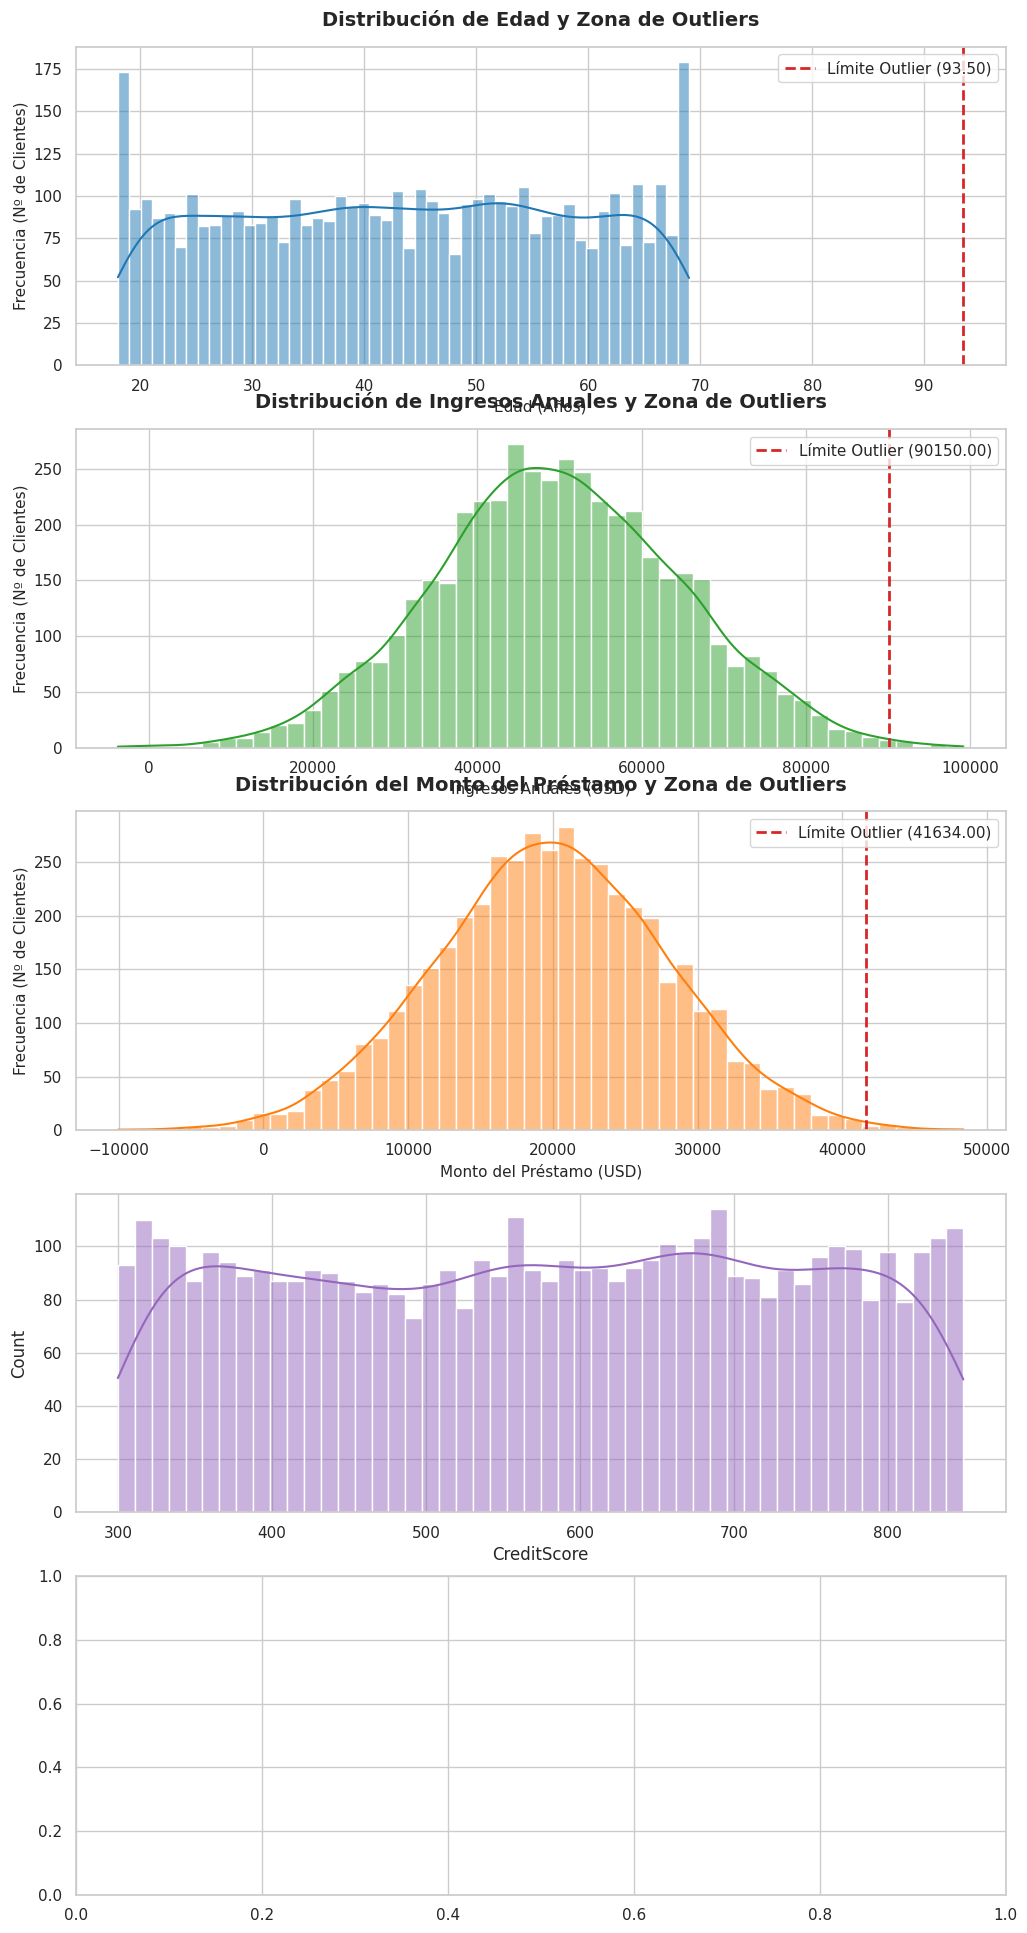

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar un estilo limpio y profesional
sns.set_theme(style="whitegrid")

# Ajustamos a 5 filas ya que son 5 gráficos, y aumentamos el alto a 24
fig, axes = plt.subplots(5, 1, figsize=(12, 24))

# Paleta de colores
base_color = "#1f77b4"  # Azul
alert_color = "#d62728" # Rojo

# --- 1. GRÁFICO: EDAD (Age) ---
sns.histplot(ax=axes[0], data=df, x='Age', kde=True, color=base_color, bins=50)
axes[0].axvline(lim_sup_age, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_age:.2f})')
axes[0].set_title('Distribución de Edad y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Edad (Años)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[0].legend(fontsize=11, loc='upper right')

# GRÁFICO: INGRESOS (Income)
sns.histplot(ax=axes[1], data=df, x='Income', kde=True, color="#2ca02c", bins=50)
axes[1].axvline(lim_sup_income, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_income:.2f})')
axes[1].set_title('Distribución de Ingresos Anuales y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Ingresos Anuales (USD)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')

# GRÁFICO: MONTO DEL PRÉSTAMO (LoanAmount)
sns.histplot(ax=axes[2], data=df, x='LoanAmount', kde=True, color="#ff7f0e", bins=50)
axes[2].axvline(lim_sup_loan, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_loan:.2f})')
axes[2].set_title('Distribución del Monto del Préstamo y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Monto del Préstamo (USD)', fontsize=11)
axes[2].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[2].legend(fontsize=11, loc='upper right')

# GRÁFICO: HISTORIAL CREDITICIO (CreditScore)
sns.histplot(ax=axes[3], data=df, x='CreditScore', kde=True, color="#9467bd", bins=50)
axes[3].axvline(lim_sup_credit, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_credit:.2f})')
axes[3].set_title('Distribución del Puntaje de Crédito y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[3].set_xlabel('Puntaje de Crédito', fontsize=11)
axes[3].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[3].legend(fontsize=11, loc='upper right')

# GRÁFICO: EXPERIENCIA LABORAL (YearsExperience)
sns.histplot(ax=axes[4], data=df, x='YearsExperience', kde=True, color="#e377c2", bins=50)
axes[4].axvline(lim_sup_experience, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_experience:.2f})')
axes[4].set_title('Distribución de Años de Experiencia y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[4].set_xlabel('Años de Experiencia', fontsize=11)
axes[4].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[4].legend(fontsize=11, loc='upper right')

# Ajustar y guardar el resultado
plt.tight_layout()
plt.savefig('assets/histogramas_outliers.png', dpi=110, bbox_inches='tight')
plt.show()
# GRÁFICO: Age
sns.histplot(ax=axes[0], data=df, x='total_trip_spend_usd', kde=True, color=base_color, bins=50)
axes[0].axvline(lim_sup_age, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_age:.2f})')
axes[0].set_title('Distribución de Gasto Total del Viaje y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Gasto Total (USD)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[0].legend(fontsize=11, loc='upper right')

# GRÁFICO: PRESUPUESTO POR PERSONA
sns.histplot(ax=axes[1], data=df, x='budget_per_person_usd', kde=True, color="#2ca02c", bins=50)
axes[1].axvline(lim_sup_budget, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_budget:.2f})')
axes[1].set_title('Distribución de Presupuesto por Persona y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Presupuesto por Persona (USD)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')

#  GRÁFICO: GASTO EN RESTAURANTES
sns.histplot(ax=axes[2], data=df, x='restaurant_spend_per_day_usd', kde=True, color="#ff7f0e", bins=50)
axes[2].axvline(lim_sup_restaurant_spend, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_restaurant_spend:.2f})')
axes[2].set_title('Distribución de Gasto Diario en Restaurantes y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Gasto Diario en Restaurantes (USD)', fontsize=11)
axes[2].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[2].legend(fontsize=11, loc='upper right')

# Ajustar espacios para que no se pisen los títulos
plt.tight_layout()
plt.show()

**Decisión:** `Age`, `CreditScore` y `YearsExperience` no presentan
outliers relevantes. `Income` y `LoanAmount` tienen un pequeño número de valores extremos (<1% de las filas). En vez de eliminarlos (perderíamos filas y, con ellas, información de otras columnas), los **capamos (winsorización)** a los límites del IQR.

In [ ]:
# Tratamiento de outliers (exploratorio): generamos df_final_sin_outliers
# para cuantificar el impacto de eliminar outliers en las 2 variables
# financieras.
# NOTA: esta variable es solo de diagnóstico y no se usa en
# el pipeline final (FASE 4 en adelante trabaja sobre 'df' o 'df_clean').

# Creamos una copia de seguridad del DataFrame original antes de modificarlo
df_clean = df.copy()

# Calcular los límites IQR necesarios para el diagnóstico
_, lim_sup_income = identificar_outliers_iqr(df, 'Income')
_, lim_sup_loan = identificar_outliers_iqr(df, 'LoanAmount')

# El límite inferior por IQR suele ser negativo para estas variables,
# pero usamos el mínimo real del dataset (df['Columna'].min()) o 0 para asegurar el filtro.
lim_inf_income = df['Income'].min()
lim_inf_loan = df['LoanAmount'].min()

# Filtrar aplicando los límites de las 2 columnas a la vez
df_final_sin_outliers = df[
    (df['Income'] >= lim_inf_income) & (df['Income'] <= lim_sup_income) &
    (df['LoanAmount'] >= lim_inf_loan) & (df['LoanAmount'] <= lim_sup_loan)
]

# Reporte de diagnóstico en pantalla
print(f" ¡Diagnóstico de limpieza financiera completado!")
print(f"  - Filas iniciales: {len(df)}")
print(f"  - Filas tras remover TODOS los outliers: {len(df_final_sin_outliers)}")
print(f"  - Total de filas eliminadas: {len(df) - len(df_final_sin_outliers)}")
print(f"  - Porcentaje de pérdida de información: {((len(df) - len(df_final_sin_outliers)) / len(df)) * 100:.2f}%")

Análisis de Outliers para la columna: Income
  - Límite Inferior aceptable: 9270.00
  - Límite Superior aceptable: 90150.00
  - Cantidad de outliers detectados: 32 de 4621 filas (0.69%)
Análisis de Outliers para la columna: LoanAmount
  - Límite Inferior aceptable: -1640.50
  - Límite Superior aceptable: 41483.50
  - Cantidad de outliers detectados: 30 de 4621 filas (0.65%)
 ¡Diagnóstico de limpieza financiera completado!
  - Filas iniciales: 4621
  - Filas tras remover TODOS los outliers: 4591
  - Total de filas eliminadas: 30
  - Porcentaje de pérdida de información: 0.65%


In [ ]:
# Configurar Pandas para que muestre TODAS las columnas sin recortes
pd.set_option('display.max_columns', None)

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


### Tratamiento de Variables Categóricas

In [ ]:
# Tratamiento de Variables Categóricas Binarias
# Definimos el diccionario de mapeo limpio
mapeo_binario = {'No': 0, 'Yes': 1}

# Aplicamos el mapeo a la columna correcta del dataset
df['LoanApproved'] = df['LoanApproved'].replace(mapeo_binario)

# Mostramos las primeras filas para verificar el cambio
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


### Tramiento de Variables Ordinales

In [ ]:
# EXPLORACIÓN DE CATEGORÍAS
print("Valores únicos en Gender:")
print(df['Gender'].unique())
print("-" * 40)

print("Valores únicos en Education:")
print(df['Education'].unique())
print("-" * 40)

print("Valores únicos en City:")
print(df['City'].unique())
print("-" * 40)

print("Valores únicos en EmploymentType:")
print(df['EmploymentType'].unique())
print("-" * 40)

Valores únicos en Gender:
['Female' 'Male']
----------------------------------------
Valores únicos en Education:
['High School' 'PhD' 'Unknown' 'Masters' 'Bachelors']
----------------------------------------
Valores únicos en City:
['Houston' 'San Francisco' 'New York' 'Chicago']
----------------------------------------
Valores únicos en EmploymentType:
['Unemployed' 'Self-Employed' 'Salaried']
----------------------------------------


In [ ]:
# Variables Categóricas Ordinales (Tienen un orden lógico)

# Mapeo Ordinal para Educación
# (Ajusta las etiquetas según los valores exactos que tengas en tu dataset)
mapeo_educacion = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

df['Education'] = df['Education'].replace(mapeo_educacion)

In [ ]:
# Variables Categóricas Ordinales (Tienen un orden lógico)

# Mapeo para Género
mapeo_genero = {'Female': 0, 'Male': 1}
df['Gender'] = df['Gender'].replace(mapeo_genero)

In [ ]:
# Tratamiento de Variables Categóricas Nominales
# Definimos las columnas que queremos procesar
columnas_nominales = ['City', 'EmploymentType']

# Verificamos si aún existen en el DataFrame antes de aplicar get_dummies
if all(col in df.columns for col in columnas_nominales):
    df = pd.get_dummies(df, columns=columnas_nominales, drop_first=True, dtype=int)
    print("¡One-Hot Encoding aplicado con éxito por primera vez!")
else:
    print("Las columnas 'City' y 'EmploymentType' ya habían sido transformadas. ¡Puedes continuar sin problemas!")

# Inspeccionamos el resultado final
df.head()

Las columnas 'City' y 'EmploymentType' ya habían sido transformadas. ¡Puedes continuar sin problemas!


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,LoanApproved,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,0,0,1,0,0,0,1
1,69,57462.0,23262.0,586.0,6,1,0,0,0,0,1,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,0,0,1,0
3,32,56307.0,11531.0,549.0,11,1,Unknown,0,0,1,0,0,1
4,60,37034.0,27871.0,500.0,19,0,0,0,0,0,0,0,1


<a id='fase-3'></a>
## FASE 3 - EDA Multivariado

Analizamos cómo se relacionan las variables entre sí y, sobre todo, con la
variable objetivo `LoanApproved`.

Tasa de aprobación global: 23.8%


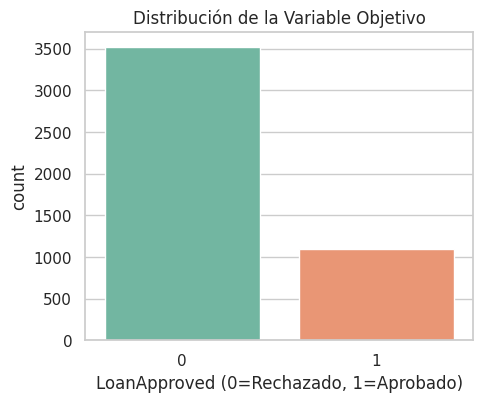

In [ ]:
tasa_aprobacion = df['LoanApproved'].mean()
print(f"Tasa de aprobación global: {tasa_aprobacion*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='LoanApproved', palette='Set2')
plt.title('Distribución de la Variable Objetivo')
plt.xlabel('LoanApproved (0=Rechazado, 1=Aprobado)')
plt.savefig('assets/target_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

**Desbalanceo de clases:** solo el ~23% de las solicitudes se
aprueban. Esto es importante para más adelante: la **accuracy** sola
puede ser engañosa (un modelo que prediga siempre "rechazado" acertaría
~77% de las veces sin aprender nada útil), así que daremos más peso a
**precision, recall, F1 y ROC-AUC**, y usaremos `class_weight='balanced'`
en los modelos que lo soporten.

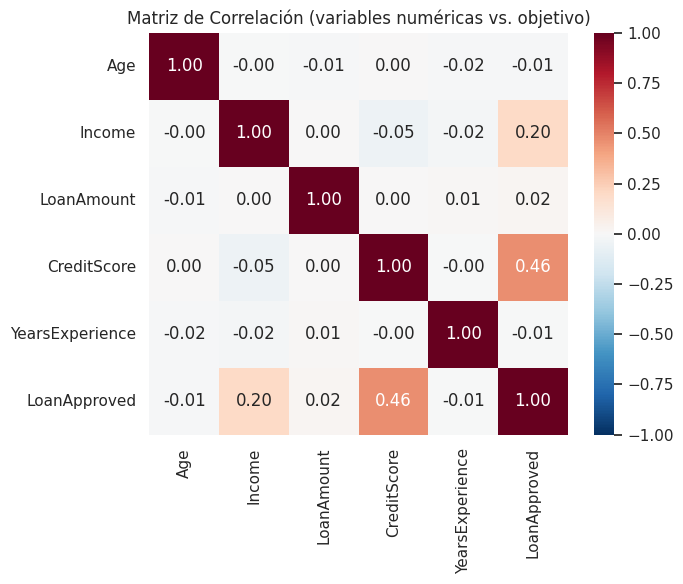

In [ ]:
columnas_numericas = ['Age','Income','LoanAmount','CreditScore','YearsExperience','LoanApproved']
corr_matrix = df[columnas_numericas].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlación (variables numéricas vs. objetivo)')
plt.tight_layout()
plt.savefig('assets/correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

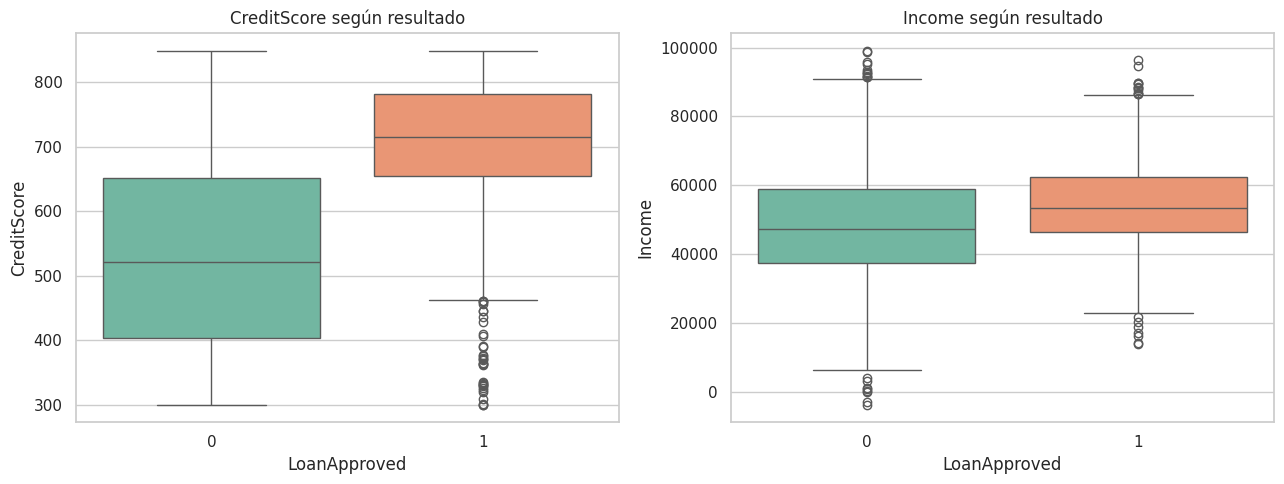

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='LoanApproved', y='CreditScore', palette='Set2', ax=axes[0])
axes[0].set_title('CreditScore según resultado')
sns.boxplot(data=df, x='LoanApproved', y='Income', palette='Set2', ax=axes[1])
axes[1].set_title('Income según resultado')
plt.tight_layout()
plt.savefig('assets/boxplots_target.png', dpi=110, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15,11))
for ax, col in zip(axes.flat, ['EmploymentType', 'Education', 'City', 'Gender']):
    tasa = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.index, y=tasa.values, palette='Set2', ax=ax)
    ax.axhline(tasa_aprobacion, color='red', linestyle='--', linewidth=1, label='Media global')
    ax.set_title(f'Tasa de aprobación por {col}')
    ax.set_ylabel('Tasa de aprobación')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
plt.tight_layout()
plt.savefig('assets/approval_rate_by_category.png', dpi=110, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

**Insights del EDA:**
- `CreditScore` es, con diferencia, la variable numérica más relacionada
  con la aprobación (correlación ≈ 0.46): a mayor score, más probabilidad
  de aprobación.
- `Income` también correlaciona positivamente, aunque más débilmente
  (≈ 0.19).
- `LoanAmount`, `Age` y `YearsExperience` apenas correlacionan con el
  resultado.
- `EmploymentType` es muy determinante: los solicitantes **desempleados**
  tienen una tasa de aprobación drásticamente menor (~3%) frente a
  asalariados o autónomos (~33%). Tiene pleno sentido de negocio: la
  capacidad de repago es central en el riesgo crediticio.
- `Gender`, `City` y `Education` apenas muestran diferencias en la tasa de
  aprobación — buena señal: el dataset no parece tener un sesgo evidente
  sobre atributos sensibles como el género.